In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Memory for superdense SE circuit scheme

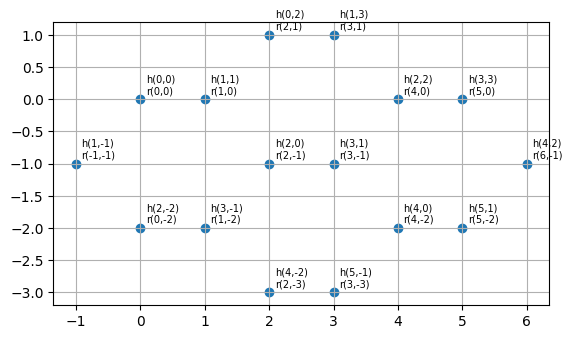

In [2]:
pos_lst = [(0,0), (1,1), (0,2), (1,3), (2,2), (3,3), (4,2), (3,1), (2,0), (1,-1), (2,-2), (3,-1), (4,0), (5,1),(4,-2),(5,-1)]

pos_lst = [Position3DHex(x[0], x[1], 0) for x in pos_lst]

pos_rec_lst = [pos.rectangular_map() for pos in pos_lst]

pos_lst = [(el.x, el.y) for el in pos_lst]

xs, ys = zip(*pos_rec_lst)
plt.scatter(xs, ys)

for (hx, hy), (rx, ry) in zip(pos_lst, pos_rec_lst):
    plt.annotate(f"h({hx},{hy})\nr({rx},{ry})", (rx, ry), textcoords="offset points", xytext=(4, 4), fontsize=7)

plt.gca().set_aspect('equal')
plt.grid(True)
plt.show()

In [3]:
g = PrismGraph("two-patches")

prisms = [
    (Position3DHex(0,0,-1), "ZN", "init"),
    (Position3DHex(0,0,0), "NZ", "left"),
    (Position3DHex(1,1,0), "ZN", "right"),
    (Position3DHex(1,1,1), "NZ", "final"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

In [4]:
d=3

SE = se.SyndromeExtractionStimCC(g, d)

SE. retrieve_stabilizers_operators()

SE.prism_graph.prism_pipes_to_data_qubits_full[0]

stabilizer tests passed


{Prism(position=Position3DHex(x=0, y=0, z=0), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.Z: 'Z'>), label='left'): [Position3DHex(x=3, y=-1, z=0),
  Position3DHex(x=1, y=1, z=0),
  Position3DHex(x=0, y=0, z=0),
  Position3DHex(x=3, y=1, z=0),
  Position3DHex(x=2, y=0, z=0),
  Position3DHex(x=4, y=-2, z=0),
  Position3DHex(x=2, y=2, z=0)],
 Prism(position=Position3DHex(x=1, y=1, z=0), kind=ZXPrism(prep=<BasisPrism.Z: 'Z'>, meas=<BasisPrism.N: 'N'>), label='right'): [Position3DHex(x=6, y=-2, z=0),
  Position3DHex(x=6, y=0, z=0),
  Position3DHex(x=7, y=1, z=0),
  Position3DHex(x=4, y=2, z=0),
  Position3DHex(x=7, y=-1, z=0),
  Position3DHex(x=5, y=1, z=0),
  Position3DHex(x=8, y=0, z=0)],
 PrismPipe(u=Prism(position=Position3DHex(x=1, y=1, z=0), kind=ZXPrism(prep=<BasisPrism.Z: 'Z'>, meas=<BasisPrism.N: 'N'>), label='right'), v=Prism(position=Position3DHex(x=0, y=0, z=0), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.Z: 'Z'>), label='left'), kind=PrismPipeKind(hor=<B

In [5]:
#mapping_full = SE.hex_mapping_to_quadratic()

In [6]:
stab = [
    Position3DHex(2,0,0),
    Position3DHex(3,1,0),
    Position3DHex(4,0,0),
    #Position3DHex(5,-1,0),
    #Position3DHex(4,-2,0),
    #Position3DHex(3,-1,0)
    ]
stabinfo = SE.assign_stabilizer_info(stab)

print("---")
print(stabinfo.data_qubits)
print([el.rect for el in stabinfo.top])
print([el.rect for el in stabinfo.sides])
print([el.rect for el in stabinfo.bottom])
print([el.rect for el in stabinfo.ancilla])


---
[PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=None), PositionEntry(hex=Position3DHex(x=3, y=1, z=0), rect=(3, -1), label=None), PositionEntry(hex=Position3DHex(x=4, y=0, z=0), rect=(4, -2), label=None)]
[(2, -1), (3, -1)]
[(4, -2)]
[]
[(2, -2), (3, -2)]


In [7]:
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.dct_stabilizers_all[0]

stabilizer tests passed


{(Position3DHex(x=2, y=0, z=0),
  Position3DHex(x=3, y=-1, z=0),
  Position3DHex(x=3, y=1, z=0),
  Position3DHex(x=4, y=-2, z=0),
  Position3DHex(x=4, y=0, z=0),
  Position3DHex(x=5, y=-1, z=0)): 'XZ',
 (Position3DHex(x=4, y=0, z=0), Position3DHex(x=5, y=-1, z=0)): 'X',
 (Position3DHex(x=4, y=-2, z=0),
  Position3DHex(x=5, y=-1, z=0),
  Position3DHex(x=6, y=-2, z=0)): 'X',
 (Position3DHex(x=1, y=1, z=0),
  Position3DHex(x=2, y=0, z=0),
  Position3DHex(x=2, y=2, z=0),
  Position3DHex(x=3, y=1, z=0)): 'XZ',
 (Position3DHex(x=4, y=2, z=0),
  Position3DHex(x=5, y=1, z=0),
  Position3DHex(x=6, y=0, z=0),
  Position3DHex(x=7, y=1, z=0)): 'XZ',
 (Position3DHex(x=4, y=0, z=0),
  Position3DHex(x=5, y=-1, z=0),
  Position3DHex(x=5, y=1, z=0),
  Position3DHex(x=6, y=-2, z=0),
  Position3DHex(x=6, y=0, z=0),
  Position3DHex(x=7, y=-1, z=0)): 'XZ',
 (Position3DHex(x=2, y=2, z=0),
  Position3DHex(x=3, y=1, z=0),
  Position3DHex(x=4, y=0, z=0),
  Position3DHex(x=4, y=2, z=0),
  Position3DHex(x=5, y=1

In [9]:
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
mapping_full = SE.hex_mapping_to_quadratic()

stabilizer tests passed


In [10]:
for z, dct in mapping_full.items():
    print(z)
    for key, values in dct.items():
        print(key)
        print("---------positions-------------")
        for pos in values.positions:
            print(pos)
        print("-----------stabs--------")
        for stab in values.stabilizers:
            print(stab)
    print("____")

-1
ZNPosition3DHex(x=0, y=0, z=-1)
---------positions-------------
PositionEntry(hex=Position3DHex(x=3, y=-1, z=0), rect=(1, -2), label=0)
PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=1)
PositionEntry(hex=Position3DHex(x=1, y=1, z=0), rect=(1, 0), label=2)
PositionEntry(hex=Position3DHex(x=4, y=-2, z=0), rect=(2, -3), label=3)
PositionEntry(hex=Position3DHex(x=2, y=2, z=0), rect=(4, 0), label=4)
PositionEntry(hex=Position3DHex(x=0, y=0, z=0), rect=(0, 0), label=5)
PositionEntry(hex=Position3DHex(x=3, y=1, z=0), rect=(3, -1), label=6)
-----------stabs--------
StabilizerInfo(data_qubits=[PositionEntry(hex=Position3DHex(x=1, y=1, z=0), rect=(1, 0), label=2), PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=1), PositionEntry(hex=Position3DHex(x=2, y=2, z=0), rect=(4, 0), label=4), PositionEntry(hex=Position3DHex(x=3, y=1, z=0), rect=(3, -1), label=6)], top=[], bottom=[PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=1), PositionE

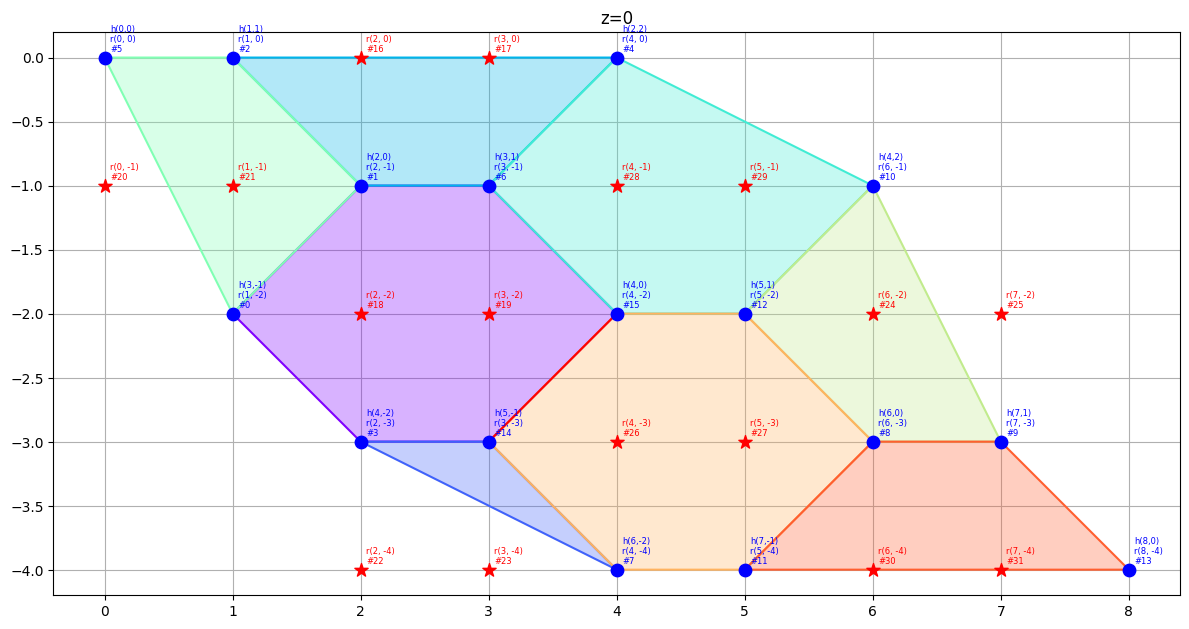

In [11]:
temp_utils.plot_mapping_full(mapping_full, 0)

## memory experiment

determine distance of circuit!!!!!

In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
g = PrismGraph("two-patches")

prisms = [
    (Position3DHex(0,0,-1), "ZZ", "init"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [11]:
rounds = 2
p = 0.01
d=7

SE = se.SyndromeExtractionStimCC(g, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
mapping_full = SE.hex_mapping_to_quadratic()
circuit, meas_rec_lst = SE.create_stim_circuit_bell_multiplexing(
    rounds = rounds,
    p_init = p,
    p_meas = p,
    p_idle = p,
    p_gate2 = p,
    cs_lst = []
)

========================z=-1=======================
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=8, y=-2, z=0), rect=(6, -5), label=12), PositionEntry(hex=Position3DHex(x=9, y=-1, z=0), rect=(7, -5), label=15)]
lst [12, 37]
lst [15, 38]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=4, y=-2, z=0), rect=(2, -3), label=29), PositionEntry(hex=Position3DHex(x=5, y=-1, z=0), rect=(3, -3), label=32)]
lst [29, 39]
lst [32, 40]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=6, y=-2, z=0), rect=(4, -4), label=24), PositionEntry(hex=Position3DHex(x=7, y=-1, z=0), rect=(5, -4), label=21)]
lst [24, 41]
lst [21, 42]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=11), PositionEntry(hex=Position3DHex(x=3, y=1, z=0), rect=(3, -1), label=16)]
lst [11, 43]
lst [16, 44]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=6, y=0, z=0), rect=(6, -3), label=26), PositionEntry(hex=Position3DHex(x=7,

In [12]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_bell_d{d}.svg", "w") as f:
    f.write(str(svg))

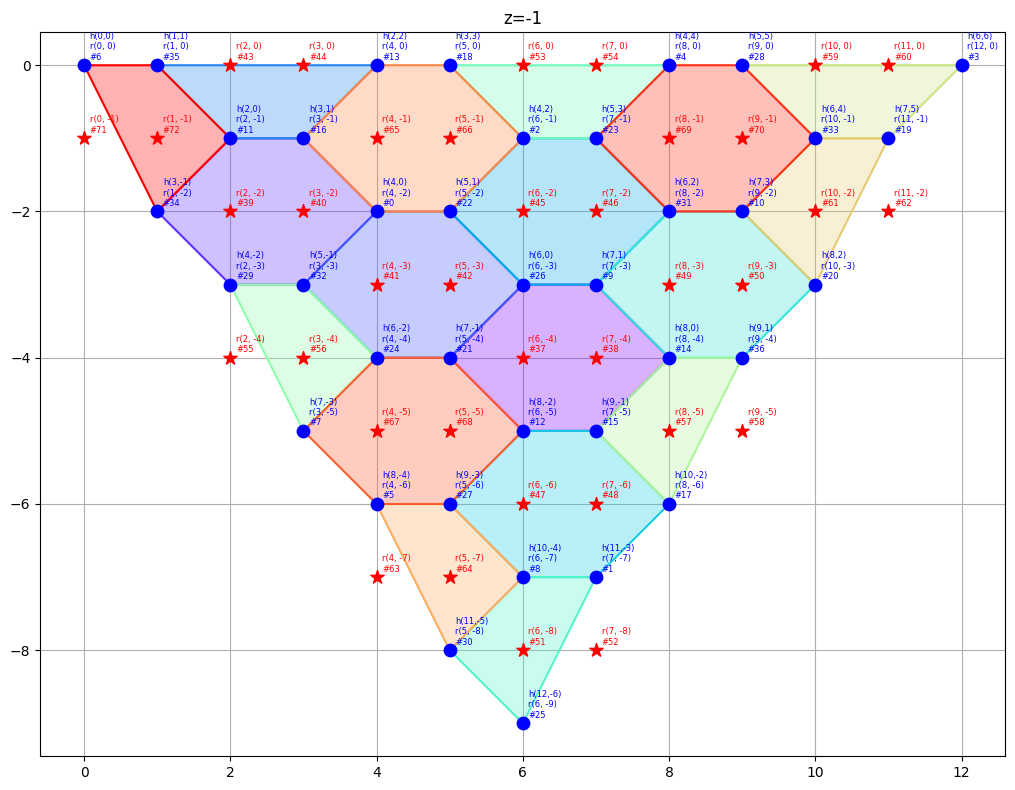

In [13]:
temp_utils.plot_mapping_full(mapping_full, -1)

In [14]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? True
Detectors that fired: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71]
  D0: fired in 16/100 shots
  D1: fired in 24/100 shots
  D2: fired in 9/100 shots
  D3: fired in 20/100 shots
  D4: fired in 15/100 shots
  D5: fired in 16/100 shots
  D6: fired in 15/100 shots
  D7: fired in 14/100 shots
  D8: fired in 10/100 shots
  D9: fired in 19/100 shots
  D10: fired in 15/100 shots
  D11: fired in 17/100 shots
  D12: fired in 16/100 shots
  D13: fired in 21/100 shots
  D14: fired in 20/100 shots
  D15: fired in 21/100 shots
  D16: fired in 19/100 shots
  D17: fired in 23/100 shots
  D18: fired in 30/100 shots
  D19: fired in 30/100 shots
  D20: fired in 31/100 shots
  D21: fired in 29/100 shots
  D22: fired in 30/100 shots
  D23: fired in 39/100 shots
  D24: fired in 33/100 shots
  D25: fired in 33

In [15]:
dem = circuit.detector_error_model()

In [16]:
def resolve_rec_indices(missing_det_circuit, total_measurements):
    detectors = []
    
    for inst in missing_det_circuit.flattened():
        targets = [
            total_measurements + target.value
            for target in inst.targets_copy()
            if target.is_measurement_record_target
        ]
        if targets:
            detectors.append(targets)
    
    return detectors

# Usage:
res = circuit.missing_detectors(unknown_input=False)
detectors = resolve_rec_indices(res, circuit.num_measurements)
for i, d in enumerate(detectors):
    print(f"Detector {i}: {d}")

In [17]:
#res = circuit.search_for_undetectable_logical_errors(
#        dont_explore_detection_event_sets_with_size_above=6,
#        dont_explore_edges_with_degree_above=9999,
#        dont_explore_edges_increasing_symptom_degree=False,
#    )

#print(f"d={len(res)}")

In [18]:
res = circuit.shortest_graphlike_error()
print(f"d={len(res)}")

d=7


## teleportation circuit superdense

In [19]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [20]:
g = PrismGraph("two-patches")

prisms = [
    (Position3DHex(0,0,-1), "XN", "init"),
    (Position3DHex(0,0,0), "NZ", "left"),
    (Position3DHex(1,1,0), "ZN", "right"),
    (Position3DHex(1,1,1), "NX", "final"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

In [21]:
g.view_as_html()

In [22]:
zx = g.to_zx_graph()
correlation_surfaces = g.find_correlation_surfaces()
cs = correlation_surfaces[0]
horizontal_pipes_cs = g.find_ver_hor_correlation_surface(cs)

for key, val in horizontal_pipes_cs.items():
    print(key)
    print(val)
    print("===")

PrismPipe(u=Prism(position=Position3DHex(x=1, y=1, z=0), kind=ZXPrism(prep=<BasisPrism.Z: 'Z'>, meas=<BasisPrism.N: 'N'>), label='right'), v=Prism(position=Position3DHex(x=0, y=0, z=0), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.Z: 'Z'>), label='left'), kind=PrismPipeKind(hor=<BasisPrism.Z: 'Z'>, ver=<BasisPrism.X: 'X'>, has_hadamard=False))
(<BasisPrism.X: 'X'>, 'hor')
===


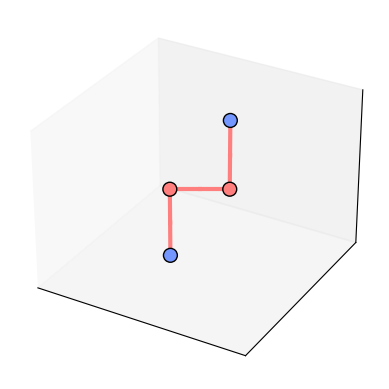

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


In [24]:
rounds = 3
p = 0.00
d=3

SE = se.SyndromeExtractionStimCC(g, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs_lst = [cs]
)

stabilizer tests passed
========================z=-1=======================
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=1), PositionEntry(hex=Position3DHex(x=3, y=1, z=0), rect=(3, -1), label=6)]
lst [1, 16]
lst [6, 17]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=4, y=-2, z=0), rect=(2, -3), label=3)]
lst [3, 18]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=3, y=-1, z=0), rect=(1, -2), label=0)]
lst [0, 21]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=1, y=1, z=0), rect=(1, 0), label=2), PositionEntry(hex=Position3DHex(x=2, y=2, z=0), rect=(4, 0), label=4)]
lst [2, 16]
lst [4, 17]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=3, y=-1, z=0), rect=(1, -2), label=0)]
lst [0, 18]
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=2, y=0, z=0), rect=(2, -1), label=1)]
lst [1, 21]
stabtype XZ, Z stab
entries []
stabtype XZ, Z stab
entries [PositionEntry(hex

In [25]:
for el in SE.meas_rec_lst:
    print("label",el.label)
    print("abs rec",el.abs_rec)
    print("meas_type", el.meas_type)
    print("z value", el.z_value)
    print("r", el.round)
    if el.stabilizer is not None:
        print([t.label for t in el.stabilizer.data_qubits])
    print("==")


label 16
abs rec 1
meas_type MX
z value -1
r 0
[2, 1, 4, 6]
==
label 17
abs rec 2
meas_type MZ
z value -1
r 0
[2, 1, 4, 6]
==
label 18
abs rec 3
meas_type MX
z value -1
r 0
[1, 0, 6, 3]
==
label 19
abs rec 4
meas_type MZ
z value -1
r 0
[1, 0, 6, 3]
==
label 20
abs rec 5
meas_type MX
z value -1
r 0
[5, 2, 1, 0]
==
label 21
abs rec 6
meas_type MZ
z value -1
r 0
[5, 2, 1, 0]
==
label 16
abs rec 7
meas_type MX
z value -1
r 1
[2, 1, 4, 6]
==
label 17
abs rec 8
meas_type MZ
z value -1
r 1
[2, 1, 4, 6]
==
label 18
abs rec 9
meas_type MX
z value -1
r 1
[1, 0, 6, 3]
==
label 19
abs rec 10
meas_type MZ
z value -1
r 1
[1, 0, 6, 3]
==
label 20
abs rec 11
meas_type MX
z value -1
r 1
[5, 2, 1, 0]
==
label 21
abs rec 12
meas_type MZ
z value -1
r 1
[5, 2, 1, 0]
==
label 16
abs rec 13
meas_type MX
z value -1
r 2
[2, 1, 4, 6]
==
label 17
abs rec 14
meas_type MZ
z value -1
r 2
[2, 1, 4, 6]
==
label 18
abs rec 15
meas_type MX
z value -1
r 2
[1, 0, 6, 3]
==
label 19
abs rec 16
meas_type MZ
z value -1
r 2
[

In [26]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_bell_teleportation_d{d}.svg", "w") as f:
    f.write(str(svg))

In [27]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? False
Detectors that fired: []


In [28]:
dem = circuit.detector_error_model()

In [29]:
dem = circuit.detector_error_model()
import stim

for instruction in dem.flattened():
    if instruction.type == "error":
        detectors = [t for t in instruction.targets_copy() 
                     if t.is_relative_detector_id()]
        logicals = [t for t in instruction.targets_copy() 
                    if t.is_logical_observable_id()]
        
        if len(detectors) == 0:
            print(f"Undetected error (p={instruction.args_copy()[0]}):")
            print(f"  Flips observables: {logicals}")
            print(f"  Full instruction: {instruction}")
def resolve_rec_indices(missing_det_circuit, total_measurements):
    detectors = []
    
    for inst in missing_det_circuit.flattened():
        targets = [
            total_measurements + target.value
            for target in inst.targets_copy()
            if target.is_measurement_record_target
        ]
        if targets:
            detectors.append(targets)
    
    return detectors

# Usage:
res = circuit.missing_detectors(unknown_input=False)

detectors = resolve_rec_indices(res, circuit.num_measurements)
for i, d in enumerate(detectors):
    print(f"Detector {i}: {d}")

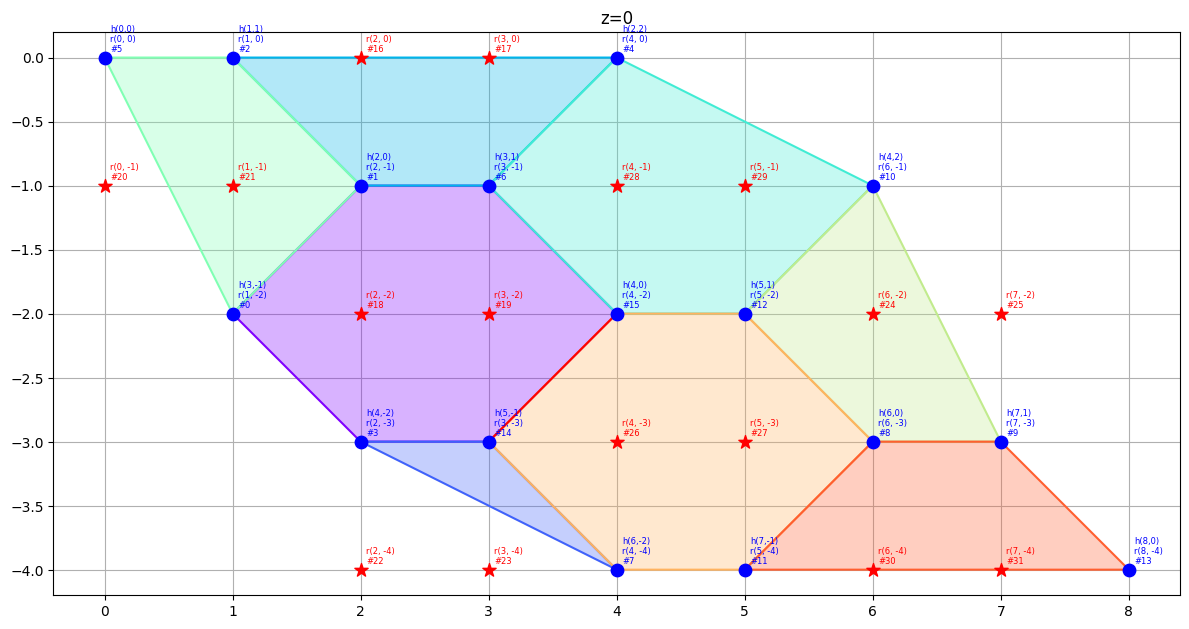

In [30]:
temp_utils.plot_mapping_full(SE.mapping_full, 0)

In [31]:
#res = circuit.shortest_graphlike_error()
#print(f"d={len(res)}")

### pipe diagrams for surface code teleportaiton

In [32]:
from tqec import BlockGraph
from tqec.utils.position import Position3D

g = BlockGraph("Teleportation")

cubes = [
    # Initial logical qubit
    (Position3D(0, 0, 0), "ZXX", "Init_Z"),

    # Intermediate teleportation structure
    (Position3D(0, 0, 1), "ZXX", ""),
    (Position3D(0, 1, 1), "ZXX", ""),

    # Output logical qubit
    (Position3D(0, 1, 2), "ZXX", "Out"),
]

cubes = [
    # Initial logical qubit
    (Position3D(0, 0, 0), "XZZ", "Init_Z"),

    # Intermediate teleportation structure
    (Position3D(0, 0, 1), "XZZ", ""),
    (Position3D(0, 1, 1), "XZZ", ""),

    # Output logical qubit
    (Position3D(0, 1, 2), "XZZ", "Out"),
]

cubes = [
    # Initial logical qubit
    (Position3D(0, 0, 0), "ZXZ", "Init_Z"),

    # Intermediate teleportation structure
    (Position3D(0, 0, 1), "ZXX", ""),
    (Position3D(0, 1, 1), "ZXX", ""),

    # Output logical qubit
    (Position3D(0, 1, 2), "ZXZ", "Out"),
]


for pos, kind, label in cubes:
    g.add_cube(pos, kind, label)

pipes = [
    # initial qubit propagated forward in time
    (0, 1),

    # entangling / teleportation connection
    (1, 2),

    # output worldline
    (2, 3),
]

for p0, p1 in pipes:
    g.add_pipe(cubes[p0][0], cubes[p1][0])

g.view_as_html()

In [33]:
correlation_surfaces = g.find_correlation_surfaces()
len(correlation_surfaces)

1

In [34]:
from tqec import compile_block_graph
compiled_computation = compile_block_graph(g, observables=[correlation_surfaces[0]])

from tqec import NoiseModel

circuit = compiled_computation.generate_stim_circuit(
    k=2,
    noise_model=NoiseModel.uniform_depolarizing(0.001),
)

In [195]:
from multiprocessing import cpu_count
import numpy as np
from pathlib import Path

from tqec import NoiseModel
from tqec.simulation.simulation import start_simulation_using_sinter


# returns a iterator
stats = start_simulation_using_sinter(
    g,
    ks=range(1, 4),  # k values for the code distance
    ps=list(np.logspace(-4, -1, 10)),  # error rates
    noise_model_factory=NoiseModel.uniform_depolarizing,  # noise model
    manhattan_radius=2,  # parameter for automatic detector computation
    observables=[correlation_surfaces[0]],  # observable of interest
    decoders=["pymatching"],
    num_workers=cpu_count(),
    max_shots=10_000_000,
    max_errors=500,
    save_resume_filepath=Path("./_examples_database/quick_start.csv"),
    database_path=Path("./_examples_database/database.pkl"),
)

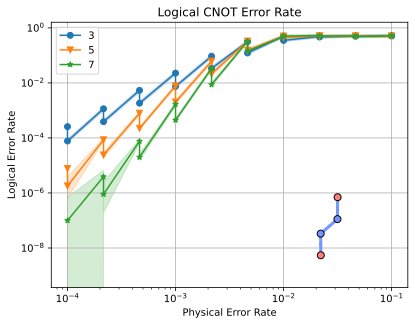

In [197]:
import matplotlib.pyplot as plt
import sinter

from tqec.simulation.plotting.inset import plot_observable_as_inset

zx_graph = g.to_zx_graph()

fig, ax = plt.subplots()
# len(stats) = 1 if we have multiple we can iterate over the results
sinter.plot_error_rate(
    ax=ax,
    stats=next(iter(stats)),
    x_func=lambda stat: stat.json_metadata["p"],
    group_func=lambda stat: stat.json_metadata["d"],
)
plot_observable_as_inset(ax, zx_graph, correlation_surfaces[0])
ax.grid(axis="both")
ax.legend()
ax.loglog()
ax.set_title("Logical CNOT Error Rate")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
plt.show()

### sanity check solve linear algebra problem for stabilizer product

In [18]:
import numpy as np

def gf2_rref(M):
    """Row reduce M over GF(2), return (rref matrix, list of pivot columns)."""
    M = M.copy() % 2
    rows, cols = M.shape
    pivot_rows = []
    pivot_cols = []
    cur_row = 0
    for col in range(cols):
        # Find pivot row
        pivot = None
        for row in range(cur_row, rows):
            if M[row, col] == 1:
                pivot = row
                break
        if pivot is None:
            continue
        # Swap
        M[[cur_row, pivot]] = M[[pivot, cur_row]]
        pivot_rows.append(cur_row)
        pivot_cols.append(col)
        # Eliminate all other rows (full RREF, not just upper triangular)
        for row in range(rows):
            if row != cur_row and M[row, col] == 1:
                M[row] = (M[row] + M[cur_row]) % 2
        cur_row += 1
    return M, pivot_cols

def solve_gf2(H, logical):
    """
    Find a in GF(2)^r such that H.T @ a = logical (mod 2).
    H:       (r x n) check matrix
    logical: (n,)   binary vector
    Returns: coefficient vector a of length r, or None if no solution.
    """
    H_T = H.T                          # (n x r)
    n, r = H_T.shape
    # Augmented matrix [H_T | logical]
    aug = np.hstack([H_T, logical.reshape(-1, 1)]) % 2  # (n x r+1)
    rref, pivots = gf2_rref(aug)

    # Check consistency
    for row in rref:
        if all(row[:-1] == 0) and row[-1] == 1:
            return None  # inconsistent

    # Extract particular solution
    a = np.zeros(r, dtype=int)
    for i, col in enumerate(pivots):
        if col < r:  # not the augmented column
            a[col] = rref[i, -1]
    return a

In [19]:
SE = se.SyndromeExtractionStimCC(g, d)
SE.retrieve_stabilizers_operators()
SE.create_mapping()
print("self.mapping:")
print(SE.mapping)

H_X = SE.check_matrix(z=0, stab_type = "X")
num_qubits, num_checks = np.shape(H_X)[1], np.shape(H_X)[0]
print(num_qubits, num_checks)

stabilizer tests passed
self.mapping:
{Position3DHex(x=3, y=-1, z=0): 0, Position3DHex(x=2, y=0, z=0): 1, Position3DHex(x=1, y=1, z=0): 2, Position3DHex(x=4, y=-2, z=0): 3, Position3DHex(x=2, y=2, z=0): 4, Position3DHex(x=0, y=0, z=0): 5, Position3DHex(x=3, y=1, z=0): 6, Position3DHex(x=6, y=-2, z=0): 7, Position3DHex(x=6, y=0, z=0): 8, Position3DHex(x=7, y=1, z=0): 9, Position3DHex(x=4, y=2, z=0): 10, Position3DHex(x=7, y=-1, z=0): 11, Position3DHex(x=5, y=1, z=0): 12, Position3DHex(x=8, y=0, z=0): 13, Position3DHex(x=5, y=-1, z=0): 14, Position3DHex(x=4, y=0, z=0): 15}
16 9


/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/temp-laura/temp_utils.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


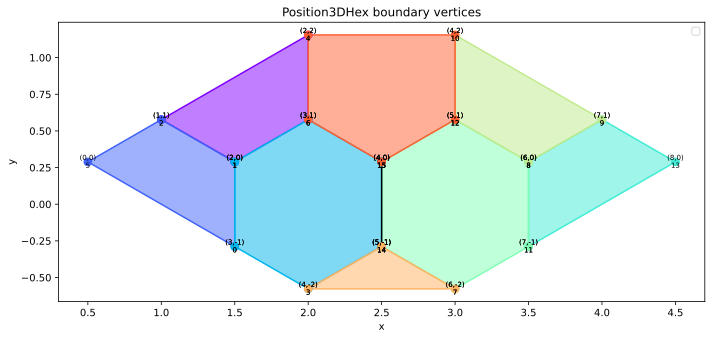

In [20]:
z=0
temp_utils.plot_position_dict(size = (10,5),stabilizers = SE.result_dct[z]["stabs"][0], mapping=SE.mapping)

In [21]:
idx_lst = [0,2,6,9,11,12]
lst = np.zeros(shape = (num_qubits, 1))
for idx in idx_lst:
    lst[idx,0]=1
print("lst logical", lst)

l_X = np.array(lst, dtype=int)   # logical X support

a = solve_gf2(H_X, l_X)
if a is not None:
    print("Coefficients a:", a)
    print("Verification:", H_X.T @ a % 2)  # should equal l_X
else:
    print("No solution found")

lst logical [[1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]]
Coefficients a: [1 0 1 0 1 1 1 1 1]
Verification: [1 0 1 0 0 0 1 0 0 1 0 1 1 0 0 0]


In [22]:
H_X

array([[0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1]])

In [23]:
H_X.T

array([[0, 1, 1, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 1, 0, 0, 1, 0],
       [0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 1],
       [0, 0, 0, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 1],
       [0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 1, 0, 1, 1, 0],
       [0, 0, 1, 0, 1, 0, 1, 0, 1]])

the only stabilizers that are not in the solution are those 0,1,2,5 and 8,9,11,3 which makes perfect sense. thus this is a much quicker solution than my exact geometric construction